# Graph classification sweep performance 

Plots showing the performance for the graph classification on the Legnini data.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [1]:
LRZ = "/dss/dsshome1/05/di93tig/1_projects/"
HPC = "/home/icb/francesca.drummer/1-Projects/"

In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{HPC}InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [3]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin


## Load WandB IDs

In [4]:
GNN_sweep = "kxr7hwgq"
InterScale_sweep = "bjz79kcp"
PCATrans_sweep = "ih7ktcdt"

## Graph Classification performance

In [5]:
SWEEP_GOAL = 'robustness'

Q: Why does PCATrans not have test_f1 scores?

In [8]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, ['Ctrl', 'SHH'])

In [12]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_Ctrl,test_f1/class_SHH
0,wa1s85vv,legnini23_clas_graph_44_GCN_,44,finished,0.5,300,None,108.922151,26930,0.985939,None,0.986134,0.985739
1,09u50axy,legnini23_clas_graph_44_GCN_,43,finished,0.5,300,None,203.357832,26930,0.982002,None,0.982320,0.981672
2,w4iz5g6s,legnini23_clas_graph_44_GCN_,42,finished,0.5,300,None,99.998106,26930,0.985377,None,0.985588,0.985160
3,gubmzswr,legnini23_clas_graph_44_GCN_,41,finished,0.5,300,None,126.443923,26930,0.987064,None,0.987229,0.986895
4,4m1figsl,legnini23_clas_graph_44_GCN_,40,finished,0.5,300,None,115.535543,26930,0.989876,None,0.989978,0.989773


In [15]:
PCATrans_wandb.get_mean_and_std()

,pct_mask_nodes,radius,mean_test_acc,std_test_acc,mean_test_f1_class_0,std_test_f1_class_0,mean_test_f1_class_1,std_test_f1_class_1
0,0.00,0,1.0,0.000000,1.0,0.000000,1.000000,0.000000
1,0.00,100,1.0,0.000000,1.0,0.000000,1.000000,0.000000
2,0.00,200,1.0,0.000000,1.0,0.000000,1.000000,0.000000
3,0.00,300,1.0,0.000000,1.0,0.000000,1.000000,0.000000
4,0.10,0,0.9,0.223607,0.8,0.447214,0.933333,0.149071
5,0.10,100,1.0,0.000000,1.0,0.000000,1.000000,0.000000
6,0.10,200,0.9,0.223607,0.8,0.447214,0.933333,0.149071
7,0.10,300,1.0,0.000000,1.0,0.000000,1.000000,0.000000
8,0.25,0,0.9,0.223607,0.8,0.447214,0.933333,0.149071
9,0.25,100,0.9,0.223607,0.8,0.447214,0.933333,0.149071


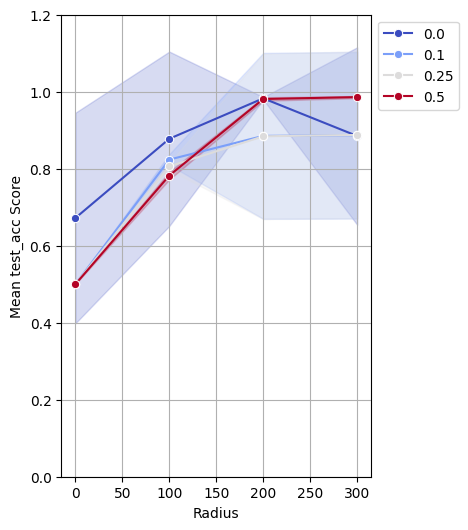

In [13]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

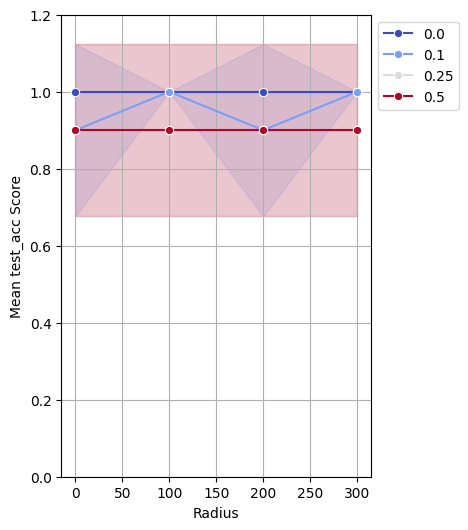

In [14]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

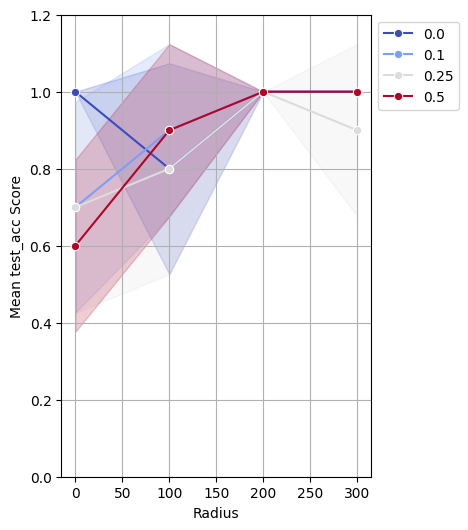

In [7]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/legnini23/graph_class")

            model class      mean       std  n_seeds
0             GCN  Ctrl  0.787233  0.440104        5
1             GCN   SHH  0.920103  0.141771        5
2      InterScale  Ctrl  1.000000  0.000000        5
3      InterScale   SHH  1.000000  0.000000        5
4  PCATransformer  Ctrl  1.000000  0.000000        5
5  PCATransformer   SHH  1.000000  0.000000        5


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/localscratch/francesca.drummer/ipykernel_2422086/2090211436.py:175: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


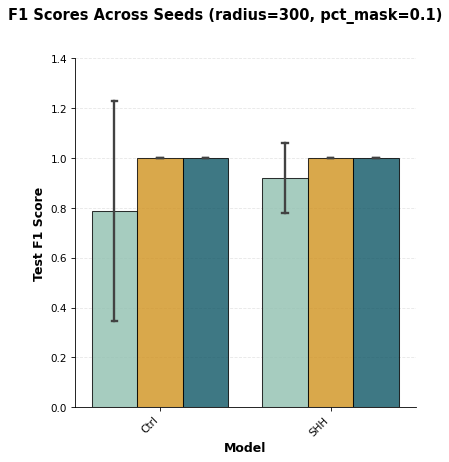

In [36]:
wandb_evals = [GNN_wandb, PCATrans_wandb, InterScale_wandb]  # Your list of dataframes

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=300,
    pct_mask_nodes=0.1,
    config_path='config.yml',
    height=6,
    aspect=0.9
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)